In [ ]:
# Setup & Imports
!pip install -q PySastrawi
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
sns.set_theme(style="darkgrid")


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Phase 2: Data Preparation & Labeling

In [ ]:
# [CELL 2] Data Loading and Label Mapping
raw_df = pd.read_csv('dataset/data.csv', encoding='latin-1')

# Mapping labels using numpy select for better efficiency
conditions = [
    (raw_df['HS'] == 1),
    (raw_df['Abusive'] == 1) & (raw_df['HS'] == 0)
]
class_choices = ['Hate Speech', 'Abusive']
raw_df['Category'] = np.select(conditions, class_choices, default='Neutral')

print("Dataset Information:")
print(raw_df['Category'].value_counts())
display(raw_df[['Tweet', 'Category']].head())

Dataset Information:
Category
Neutral        5860
Hate Speech    5561
Abusive        1748
Name: count, dtype: int64


,Tweet,Category
0,- disaat semua cowok berusaha melacak perhatia...,Hate Speech
1,RT USER: USER siapa yang telat ngasih tau elu?...,Abusive
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",Neutral
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,Neutral
4,USER USER Kaum cebong kapir udah keliatan dong...,Hate Speech


Phase 3: Text Preprocessing Pipeline

In [ ]:
# Load External Dictionaries for mapping
slang_data = pd.read_csv('dataset/new_kamusalay.csv', encoding='latin-1', header=None)
slang_dict = pd.Series(slang_data[1].values, index=slang_data[0]).to_dict()

id_stopwords = set(stopwords.words('indonesian'))
# PERBAIKAN DI SINI: menggunakan create_stemmer()
id_stemmer = StemmerFactory().create_stemmer()

# Consolidated Text Preprocessing Function
def text_cleaner(sentence):
    text = str(sentence).lower()
    text = re.sub(r'\\x[a-f0-9]{2}', ' ', text)
    text = re.sub(r'\b(rt|user|url)\b', ' ', text)
    text = re.sub(r'[^a-z]+', ' ', text).strip()
    
    words = text.split()
    final_tokens = []
    
    for word in words:
        formal_word = slang_dict.get(word, word)
        if formal_word not in id_stopwords:
            stemmed_word = id_stemmer.stem(formal_word)
            if stemmed_word: 
                final_tokens.append(stemmed_word)
                
    return ' '.join(final_tokens)

print("Text cleaning process is running... (This might take a while)")
raw_df['Clean_Text'] = raw_df['Tweet'].apply(text_cleaner)
display(raw_df[['Tweet', 'Clean_Text']].sample(5))

Text cleaning process is running... (This might take a while)


,Tweet,Clean_Text
6753,RT USER: pada akhirnya si orang pintar yg jadi...,sih orang pintar gila mati mati mati sama lang...
11895,USER Kleb aseng yang kena banned \xf0\x9f\x98\...,klub asing kena banned
1532,USER USER USER USER USER USER USER USER USER U...,ya lucu nada manusia kena pecah bom cacat umur...
1828,USER balesnya lama banget ih si pecun :( gerce...,balas banget ih sih pecun gerak cepat ah
11984,"RT USER: Jangan jadikan bodoh, babi ,sial tu s...",jadi bodoh babi sial zikir hari moga kurang ja...


In [ ]:
# [CELL 4] Consolidated Text Preprocessing Function
def text_cleaner(sentence):
    # 1. Case folding & Remove Twitter entities
    text = str(sentence).lower()
    text = re.sub(r'\\x[a-f0-9]{2}', ' ', text)
    text = re.sub(r'\b(rt|user|url)\b', ' ', text)
    
    # 2. Remove punctuation and extra whitespaces
    text = re.sub(r'[^a-z]+', ' ', text).strip()
    
    # 3. Slang normalization, Stopwords removal, and Stemming in a single loop
    words = text.split()
    final_tokens = []
    
    for word in words:
        formal_word = slang_dict.get(word, word) # Check slang dictionary
        if formal_word not in id_stopwords:      # Filter stopwords
            stemmed_word = id_stemmer.stem(formal_word) # Stemming process
            if stemmed_word: 
                final_tokens.append(stemmed_word)
                
    return ' '.join(final_tokens)

# Execute cleaning (This will take a few minutes due to the Sastrawi stemmer)
print("Text cleaning process is running...")
raw_df['Clean_Text'] = raw_df['Tweet'].apply(text_cleaner)
display(raw_df[['Tweet', 'Clean_Text']].sample(5))

Text cleaning process is running...


,Tweet,Clean_Text
10215,Turut hadir pula dalam acara tersebut partai k...,hadir acara partai koalisi dukung pasang guber...
1166,"USER ayahku tsundere, dingin, jarang omongan c...",ayah tsundere dingin jarang omong canggung ora...
12432,USER USER mbak kunti-kuntinya tu lhoo \xf0\x9f...,mbak kunti kuntinya lo xb
1096,- Dia sendiri yang ngiklanin promo cashback di...,iklan promo cashback aplikasinyya guna kode ha...
13054,nih ya baca tai. udah dong jangan spam minta k...,nih ya baca tai spam kado


Phase 4: Feature Extraction & Data Splitting (80:20)

In [ ]:
# [CELL 5] Splitting Data
X_features = raw_df['Clean_Text']
y_target = raw_df['Category']

# Split Data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.20, random_state=42, stratify=y_target
)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

# [CELL 6] Initialize Vectorizers
tfidf_vec = TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True)
count_vec = CountVectorizer(ngram_range=(1,2))

# Transform Training and Testing Data
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)

X_train_count = count_vec.fit_transform(X_train)
X_test_count = count_vec.transform(X_test)

Training Samples : 10535
Testing Samples  : 2634


Phase 5: Model Training Pipeline

In [ ]:
# Defining the Model Pipeline
model_collection = {
    "Naive Bayes": (MultinomialNB(alpha=1.0), X_train_count, X_test_count),
    "K-NN": (KNeighborsClassifier(n_neighbors=5, metric='cosine', algorithm='brute'), X_train_tfidf, X_test_tfidf),
    "LogReg": (LogisticRegression(C=1.0, max_iter=1000, random_state=42), X_train_tfidf, X_test_tfidf),
    "SVM (Linear)": (SVC(kernel='linear', C=1.0, random_state=42), X_train_tfidf, X_test_tfidf)
}

evaluation_metrics = []
model_predictions = {}

# Training and Evaluation Loop
for algo_name, (model_instance, train_data, test_data) in model_collection.items():
    print(f"Training algorithm: {algo_name}...")
    
    start_t = time.time()
    
    # Fit & Predict
    model_instance.fit(train_data, y_train)
    preds = model_instance.predict(test_data)
    
    end_t = time.time()
    inference_duration = ((end_t - start_t) / len(y_test)) * 1000
    
    # Store predictions
    model_predictions[algo_name] = preds
    
    # Extract metrics
    report = classification_report(y_test, preds, output_dict=True)
    evaluation_metrics.append({
        'Algorithm': algo_name,
        'Accuracy': accuracy_score(y_test, preds),
        'Macro_Precision': report['macro avg']['precision'],
        'Macro_F1': f1_score(y_test, preds, average='macro'),
        'Precision_HS': report['Hate Speech']['precision'],
        'Recall_HS': report['Hate Speech']['recall'],
        'F1_Hate_Speech': report['Hate Speech']['f1-score'],
        'F1_Abusive': report['Abusive']['f1-score'],
        'Inference_Speed (ms)': inference_duration
    })
print("\nAll models have been successfully trained.")

Training algorithm: Naive Bayes...
Training algorithm: K-NN...
Training algorithm: LogReg...
Training algorithm: SVM (Linear)...

All models have been successfully trained.


Phase 6: Performance Evaluation & Visualizations

In [ ]:
# [CELL 9] Display Performance Comparison Table

performance_df = pd.DataFrame(evaluation_metrics)
performance_df.set_index('Algorithm', inplace=True)

final_table = performance_df[['Accuracy', 'Macro_Precision', 'Recall_HS', 'Macro_F1']].rename(
    columns={
        'Macro_Precision': 'Precision', 
        'Recall_HS': 'Recall', 
        'Macro_F1': 'F1-Score'
    }
)

# 4. Tampilkan tabel dengan styling warna (Heatmap style)
display(final_table.style.format("{:.4f}").background_gradient(cmap='YlGnBu'))

,Accuracy,Precision,Recall,F1-Score
Algorithm,,,,
Naive Bayes,0.7912,0.8189,0.8723,0.7451
K-NN,0.7024,0.6724,0.7545,0.6730
LogReg,0.8151,0.8091,0.8354,0.7825
SVM (Linear),0.8166,0.7960,0.8372,0.7865


In [ ]:
import joblib
import os

# Buat folder 'models' jika belum ada
if not os.path.exists('models'):
    os.makedirs('models')

# Simpan Vectorizers
joblib.dump(count_vec, 'models/count_vec.pkl')
joblib.dump(tfidf_vec, 'models/tfidf_vec.pkl')

# Simpan Model (Indeks 0 dari tuple model_collection adalah objek modelnya)
joblib.dump(model_collection['Naive Bayes'][0], 'models/nb_model.pkl')
joblib.dump(model_collection['K-NN'][0], 'models/knn_model.pkl')
joblib.dump(model_collection['LogReg'][0], 'models/logreg_model.pkl')
joblib.dump(model_collection['SVM (Linear)'][0], 'models/svm_model.pkl')

print("Semua model dan vectorizer berhasil disimpan ke folder 'models'!")

Semua model dan vectorizer berhasil disimpan ke folder 'models'!


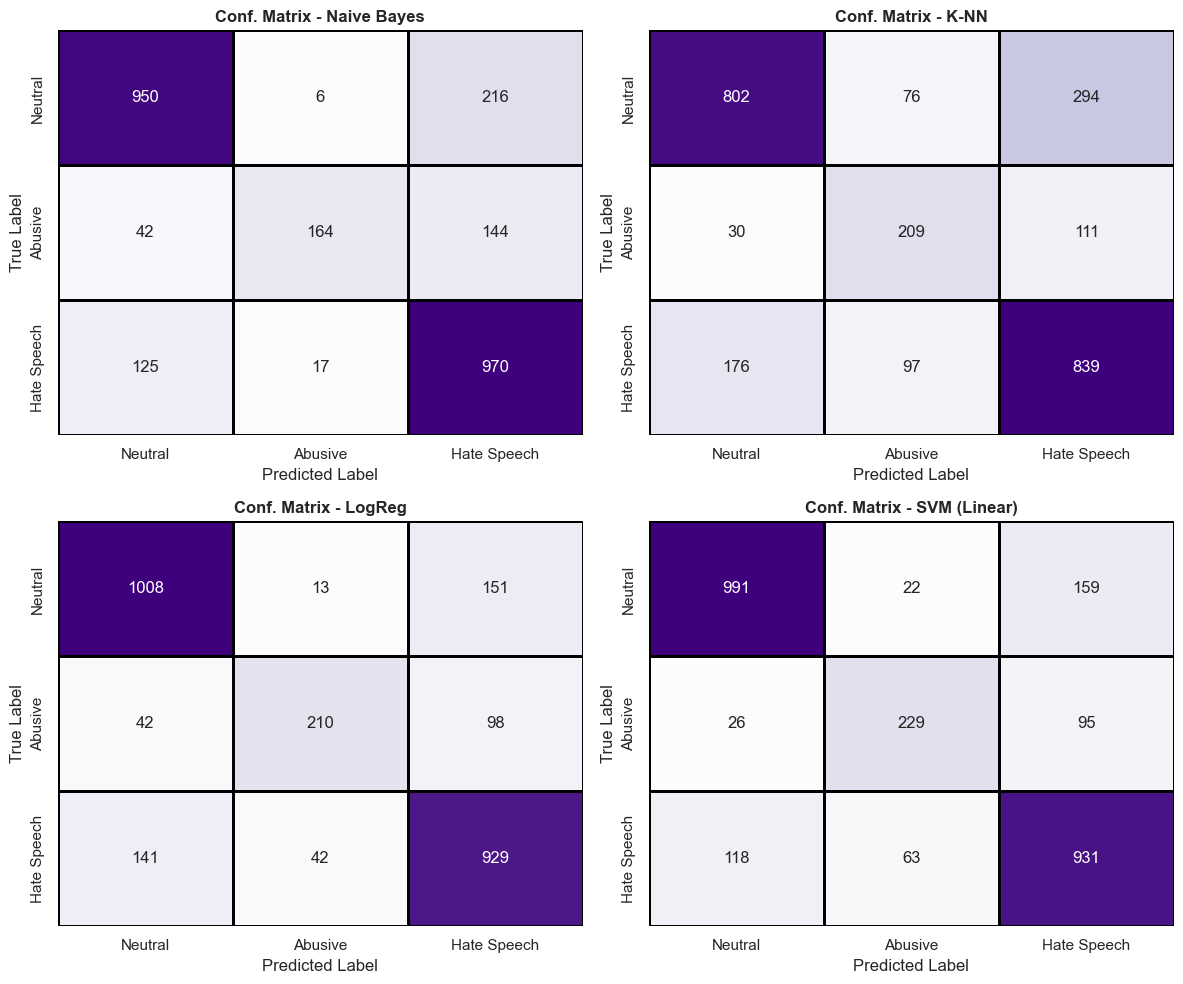

In [ ]:
# [CELL 10] Confusion Matrix Visualizations
class_order = ['Neutral', 'Abusive', 'Hate Speech']

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax = ax.flatten()

for i, (algo_name, preds) in enumerate(model_predictions.items()):
    cm = confusion_matrix(y_test, preds, labels=class_order)
    
    sns.heatmap(cm, annot=True, fmt='g', cmap='Purples', ax=ax[i], 
                xticklabels=class_order, yticklabels=class_order, 
                cbar=False, linewidths=1, linecolor='black')
    
    ax[i].set_title(f'Conf. Matrix - {algo_name}', fontweight='bold')
    ax[i].set_xlabel('Predicted Label')
    ax[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [ ]:
print("====================================================")
print("  Interactive Hate Speech & Abusive Detection Loop  ")
print("====================================================\n")
print("Instructions:")
print("- Type any sentence/tweet to test the models.")
print("- Type 'exit' or 'quit' to stop the program.\n")

while True:
    user_input = input("Enter a sentence to test: ")
    
    if user_input.lower().strip() in ['exit', 'quit']:
        print("\nProgram terminated. Thank you!")
        break
        
    if not user_input.strip():
        continue
        
    print("\nProcessing text...")
    cleaned_input = text_cleaner(user_input)
    print(f"Cleaned Text   : '{cleaned_input}'")
    print("-" * 50)
    
    # Transformasi input ke format matriks
    input_vector_count = count_vec.transform([cleaned_input])
    input_vector_tfidf = tfidf_vec.transform([cleaned_input])
    
    print(f"{'Algorithm':<20} | {'Predicted Category'}")
    print("-" * 50)
    
    # PERBAIKAN: Ambil key-nya saja dari model_collection agar lebih aman dari perubahan struktur tuple
    for algo_name in model_collection.keys():
        # Ambil objek model yang bersangkutan
        model_item = model_collection[algo_name]
        
        # Antisipasi jika model_item berbentuk tuple (3 elemen) atau cuma objek model murni
        if isinstance(model_item, tuple):
            actual_model = model_item[0]
        else:
            actual_model = model_item
            
        # Tentukan jenis vectorizer berdasarkan nama algoritmanya
        if algo_name == "Naive Bayes":
            prediction = actual_model.predict(input_vector_count)[0]
        else:
            prediction = actual_model.predict(input_vector_tfidf)[0]
            
        print(f"{algo_name:<20} | {prediction}")
        
    print("====================================================\n")

  Interactive Hate Speech & Abusive Detection Loop  

Instructions:
- Type any sentence/tweet to test the models.
- Type 'exit' or 'quit' to stop the program.

